# 01_eda.ipynb — Titanic Profiling, Cleaning, and Data Story

Load Titanic once, clean once, save titanic.csv.

In [1]:
#Run once from the command line if scikit-learn isn't installed:
! pip install -q scikit-learn

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

## Display and plot settings

In [3]:
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## Load Titanic once and save offline CSV

In [4]:
# Load the Titanic dataset exactly once.
df = sns.load_dataset("titanic")

# Immediately save the loaded dataset as the required offline snapshot.
# This creates titanic.csv before any cleaning is performed.
df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded successfully")
print("Initial titanic.csv snapshot saved successfully")

Titanic dataset loaded successfully
Initial titanic.csv snapshot saved successfully


## Profile the dataset

In [5]:
print("DATASET INFORMATION")
print("=" * 50)
df.info()

print("\nDESCRIPTIVE STATISTICS")
print("=" * 50)
print(df.describe())

print("\nDATASET SHAPE")
print("=" * 50)
print(df.shape)

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

DESCRIPTIVE STATISTICS
         survived      pclass         age       si

## Missing-value percentage

In [6]:
missing_percentage = df.isnull().mean() * 100

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

print("MISSING VALUE PERCENTAGE")
print("=" * 50)
print(missing_percentage)

MISSING VALUE PERCENTAGE
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


## Cleaning strategy — threshold rule

In [7]:
# Rule:
# < 5% missing      -> drop affected rows
# 5%-30% missing    -> impute
# Very high missing -> drop the column or encode missing as its own category

clean_df = df.copy()

missing_percentage = clean_df.isnull().mean() * 100

print("MISSING VALUE STRATEGY")
print("=" * 60)

for column, percentage in missing_percentage[missing_percentage > 0].items():
    print(f"{column}: {percentage:.2f}%")

print("\nDECISIONS")
print("=" * 60)

print(
    f"age: {missing_percentage['age']:.2f}% missing\n"
    "(5%-30% band) -> median imputation.\n"
    "Median is used because it is less affected by extreme age values \n"
    "than the mean."
    )

print(
    f"embarked: {missing_percentage['embarked']:.2f}% missing\n"
    "(< 5% band) -> drop the affected rows.\n "
    "The missing rate is negligible, so dropping the rows causes very\n"
    "little information loss."
)
print("="*60)
print(
    f"embark_town: {missing_percentage['embark_town']:.2f}% missing\n"
    "(< 5% band) -> drop the affected rows.\n"
    "The missing values occur on the same records as embarked, so the\n"
    "same row removal resolves both columns."
)
print("="*60)
print(
    f"deck: {missing_percentage['deck']:.2f}% missing\n "
    "(very high missing rate) -> drop the column.\n"
    "More than three-quarters of the values are missing, making\n"
    "imputation unreliable. Dropping the column avoids introducing\n"
    "a large amount of artificial information."
)

MISSING VALUE STRATEGY
age: 19.87%
embarked: 0.22%
deck: 77.22%
embark_town: 0.22%

DECISIONS
age: 19.87% missing
(5%-30% band) -> median imputation.
Median is used because it is less affected by extreme age values 
than the mean.
embarked: 0.22% missing
(< 5% band) -> drop the affected rows.
 The missing rate is negligible, so dropping the rows causes very
little information loss.
embark_town: 0.22% missing
(< 5% band) -> drop the affected rows.
The missing values occur on the same records as embarked, so the
same row removal resolves both columns.
deck: 77.22% missing
 (very high missing rate) -> drop the column.
More than three-quarters of the values are missing, making
imputation unreliable. Dropping the column avoids introducing
a large amount of artificial information.


## Apply the cleaning

In [8]:
# 1. Drop deck because its missing rate is very high.
clean_df = clean_df.drop(columns=["deck"])

# 2. Drop rows where embarked or embark_town is missing.
# Both have a missing rate below 5%.
clean_df = clean_df.dropna(
    subset=["embarked", "embark_town"]
)

# 3. Impute age using the median.
clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

print("Cleaning completed")
print("Cleaned shape:", clean_df.shape)

Cleaning completed
Cleaned shape: (889, 14)


## Verify cleaned data

In [9]:
print("CLEANED DATA INFORMATION")
print("=" * 50)
clean_df.info()

print("\nREMAINING MISSING VALUES")
print("=" * 50)
print(clean_df.isnull().sum())

print("\nCLEANED DATA SHAPE")
print("=" * 50)
print(clean_df.shape)

CLEANED DATA INFORMATION
<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    str     
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        889 non-null    category
 9   who          889 non-null    str     
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        889 non-null    str     
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 86.1 KB

REMAINING MISSING VALUES
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch 

## Univariate analysis — Age

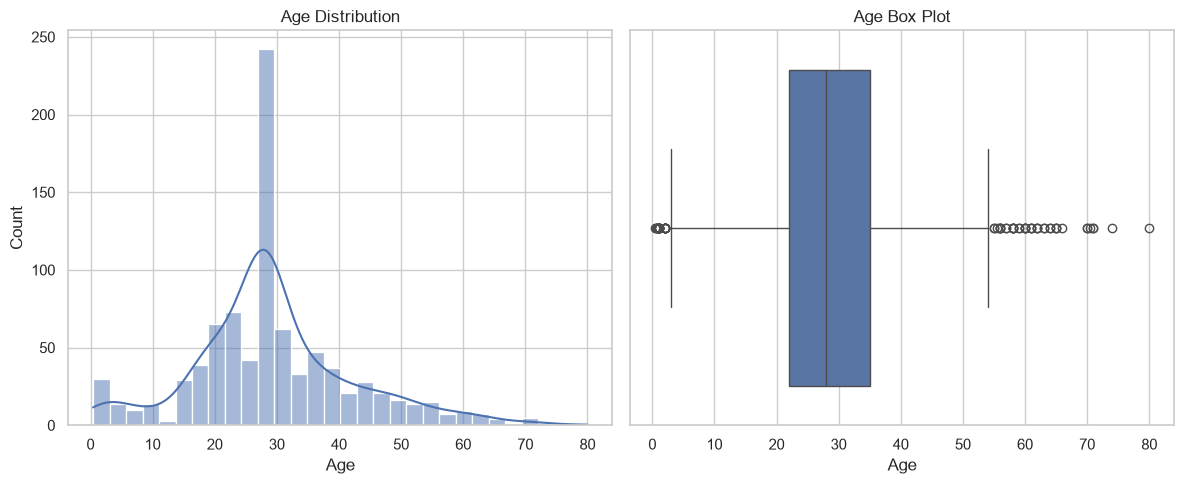

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    clean_df["age"],
    bins=30,
    kde=True
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.boxplot(
    x=clean_df["age"]
)
plt.title("Age Box Plot")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

## IQR outlier counts

In [11]:
def count_iqr_outliers(data, column):
    """
    Count outliers using the IQR rule.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing the column.
    column : str
        Name of the column to analyze.

    Returns
    -------
    pandas.DataFrame
        Rows identified as IQR outliers.
    """

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound)
        | (data[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")

    return outliers

age_outliers = count_iqr_outliers(
    clean_df,
    "age"
)

fare_outliers = count_iqr_outliers(
    clean_df,
    "fare"
)


Column: age
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower bound: 2.50
Upper bound: 54.50
Number of outliers: 65

Column: fare
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower bound: -26.76
Upper bound: 65.66
Number of outliers: 114


## Fare mean / median / mode and skew interpretation

In [12]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()
fare_skew = clean_df["fare"].skew()

print("FARE STATISTICS")
print("=" * 50)

print(f"Mean: {fare_mean:.2f}")
print(f"Median: {fare_median:.2f}")
print(f"Mode: {fare_mode.tolist()}")
print(f"Skewness: {fare_skew:.3f}")

print("\nWRITTEN INTERPRETATION")
print("=" * 50)

mode_val = fare_mode.iloc[0]

print(
    f"Fare is right-skewed. The ordering mean ({fare_mean:.2f}) > "
    f"median ({fare_median:.2f}) > mode ({mode_val:.2f}) is consistent\n"
    "with a positively skewed distribution. The high-fare passengers\n"
    "create a long right tail and pull the mean upward."
)

FARE STATISTICS
Mean: 32.10
Median: 14.45
Mode: [8.05]
Skewness: 4.801

WRITTEN INTERPRETATION
Fare is right-skewed. The ordering mean (32.10) > median (14.45) > mode (8.05) is consistent
with a positively skewed distribution. The high-fare passengers
create a long right tail and pull the mean upward.


## Bivariate analysis — survival rate using boolean masking

In [13]:
# ------------------------------------------------------------
# (a) Survival rate by sex
# ------------------------------------------------------------
female_mask = clean_df["sex"] == "female"
male_mask = clean_df["sex"] == "male"

survival_rate_female = (
    clean_df.loc[female_mask, "survived"].mean() * 100
)

survival_rate_male = (
    clean_df.loc[male_mask, "survived"].mean() * 100
)

print("SURVIVAL RATE BY SEX")
print("=" * 50)

print(f"female: {survival_rate_female:.2f}%")
print(f"male:   {survival_rate_male:.2f}%")
print("=" * 50)

# ------------------------------------------------------------
# (b) Survival rate by passenger class
# ------------------------------------------------------------
pclass_values = sorted(
    clean_df["pclass"].unique()
)

print("SURVIVAL RATE BY PASSENGER CLASS")
print("=" * 50)

for pc in pclass_values:

    pclass_mask = clean_df["pclass"] == pc

    rate = (
        clean_df.loc[pclass_mask, "survived"].mean()
        * 100
    )

    print(f"pclass {pc}: {rate:.2f}%")
    

# ------------------------------------------------------------
# (c) Survival rate by sex AND pclass
# ------------------------------------------------------------
print("=" * 50)
print("SURVIVAL RATE BY SEX AND PCLASS")
print("=" * 50)

for sex_val, sex_mask in [
    ("female", female_mask),
    ("male", male_mask)
]:

    for pc in pclass_values:

        pclass_mask = clean_df["pclass"] == pc

        combined_mask = sex_mask & pclass_mask

        rate = (
            clean_df.loc[
                combined_mask,
                "survived"
            ].mean()
            * 100
        )
       
        print(
            f"sex={sex_val}, pclass={pc}: "
            f"{rate:.2f}%"
        )

# ------------------------------------------------------------
# Additional & / | boolean masking demonstration
# ------------------------------------------------------------
first_class_mask = clean_df["pclass"] == 1

# Female AND first class
female_first_class = clean_df[
    female_mask & first_class_mask
]

female_first_class_survival = (
    female_first_class["survived"].mean() * 100
)

print(
    "\nFemale first-class passengers "
    "(female_mask & first_class_mask)"
)

print(
    f"Count: {len(female_first_class)}"
)

print(
    f"Survival rate: "
    f"{female_first_class_survival:.2f}%"
)

# Male OR third class
third_class_mask = clean_df["pclass"] == 3

male_or_third_class = clean_df[
    male_mask | third_class_mask
]

male_or_third_class_survival = (
    male_or_third_class["survived"].mean() * 100
)

print(
    "\nMale OR third-class passengers "
    "(male_mask | third_class_mask)"
)

print(
    f"Count: {len(male_or_third_class)}"
)

print(
    f"Survival rate: "
    f"{male_or_third_class_survival:.2f}%"
)

SURVIVAL RATE BY SEX
female: 74.04%
male:   18.89%
SURVIVAL RATE BY PASSENGER CLASS
pclass 1: 62.62%
pclass 2: 47.28%
pclass 3: 24.24%
SURVIVAL RATE BY SEX AND PCLASS
sex=female, pclass=1: 96.74%
sex=female, pclass=2: 92.11%
sex=female, pclass=3: 50.00%
sex=male, pclass=1: 36.89%
sex=male, pclass=2: 15.74%
sex=male, pclass=3: 13.54%

Female first-class passengers (female_mask & first_class_mask)
Count: 92
Survival rate: 96.74%

Male OR third-class passengers (male_mask | third_class_mask)
Count: 721
Survival rate: 25.10%


## Correlation matrix — exactly six columns

In [14]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[
    correlation_columns
].corr()

print("CORRELATION MATRIX")
print("=" * 50)

print(correlation_matrix)

CORRELATION MATRIX
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


## Correlation heatmap

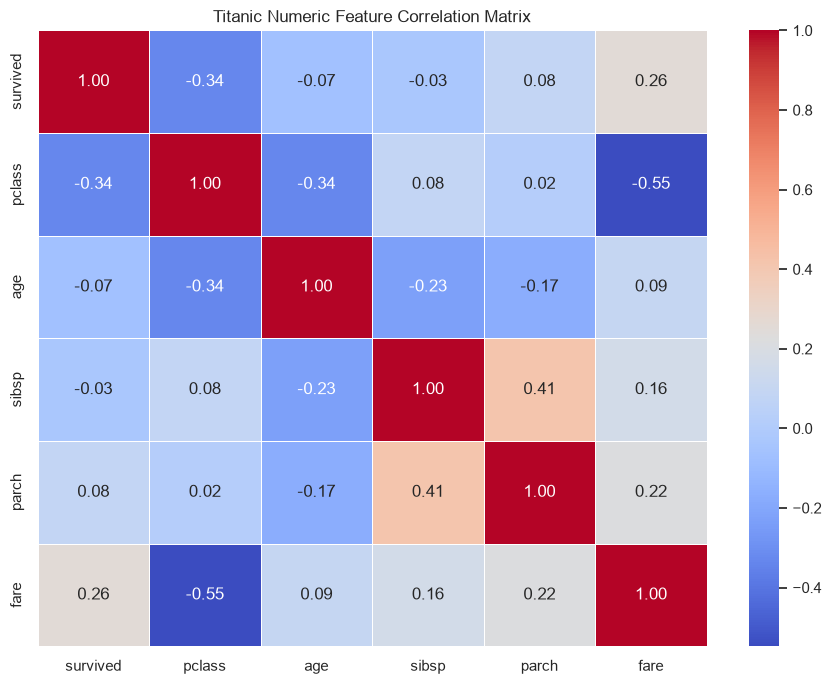

In [15]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Titanic Numeric Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()

## Rank correlations and interpret top two

In [16]:
# Keep only the upper triangle so each feature pair
# appears only once and diagonal values are excluded.
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

top_two = (
    correlation_pairs
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .head(2)
)

print("TWO STRONGEST CORRELATIONS")
print("=" * 60)

print(top_two)

print("\nWRITTEN INTERPRETATION")
print("=" * 60)

f1a, f2a, corra = top_two.iloc[0][
    ["Feature 1", "Feature 2", "Correlation"]
]

f1b, f2b, corrb = top_two.iloc[1][
    ["Feature 1", "Feature 2", "Correlation"]
]

dir_a = "negative" if corra < 0 else "positive"
dir_b = "negative" if corrb < 0 else "positive"

print(
    f"The strongest pairwise correlation is between "
    f"{f1a} and {f2a}\n"
    f"(r = {corra:.2f}, {dir_a}).\n"
    f"The second strongest is between {f1b} and {f2b}\n"
    f"(r = {corrb:.2f}, {dir_b}).\n"
    "These values represent measured linear associations\n"
    "in the cleaned Titanic data and do not establish causation."
)

TWO STRONGEST CORRELATIONS
   Feature 1 Feature 2  Correlation  Absolute Correlation
11    pclass      fare    -0.548193              0.548193
22     sibsp     parch     0.414542              0.414542

WRITTEN INTERPRETATION
The strongest pairwise correlation is between pclass and fare
(r = -0.55, negative).
The second strongest is between sibsp and parch
(r = 0.41, positive).
These values represent measured linear associations
in the cleaned Titanic data and do not establish causation.


## Multivariate data story

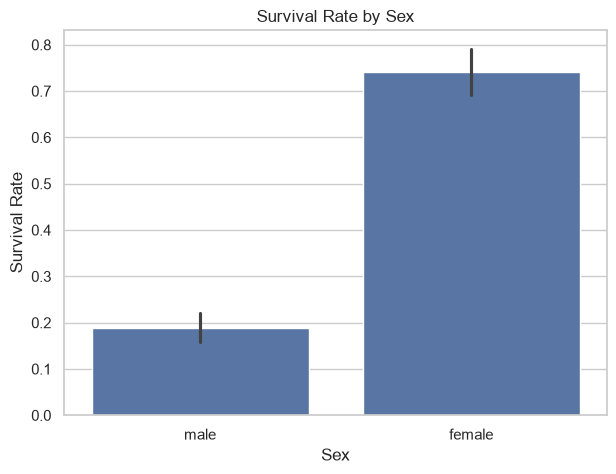

INTERPRETATION: Female passengers had a survival rate of 
74.0%, compared with 18.9% for male passengers. 
The chart shows a substantial difference in survival 
rates between the two groups in this sample.


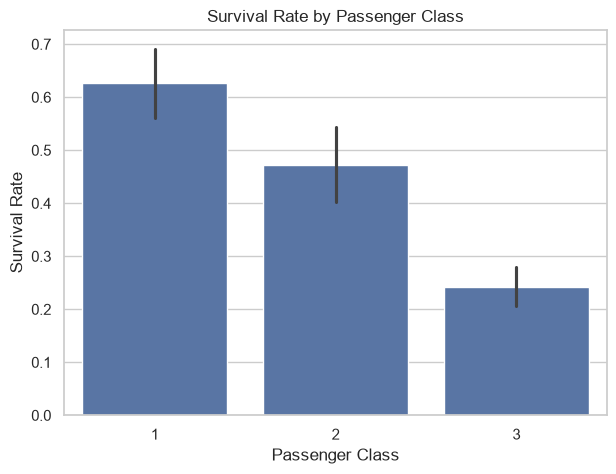

INTERPRETATION: Survival rate decreases from first 
class to third class in this dataset. This pattern is
consistent with the negative correlation between pclass
and survived observed in the correlation matrix.


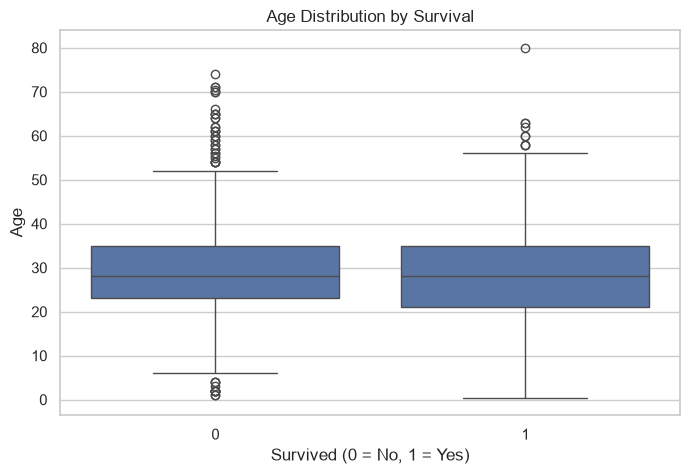

INTERPRETATION: The age distributions of survivors and 
non-survivors overlap substantially. The survivor group 
has a somewhat lower median age, although age alone does 
not clearly separate the two groups.


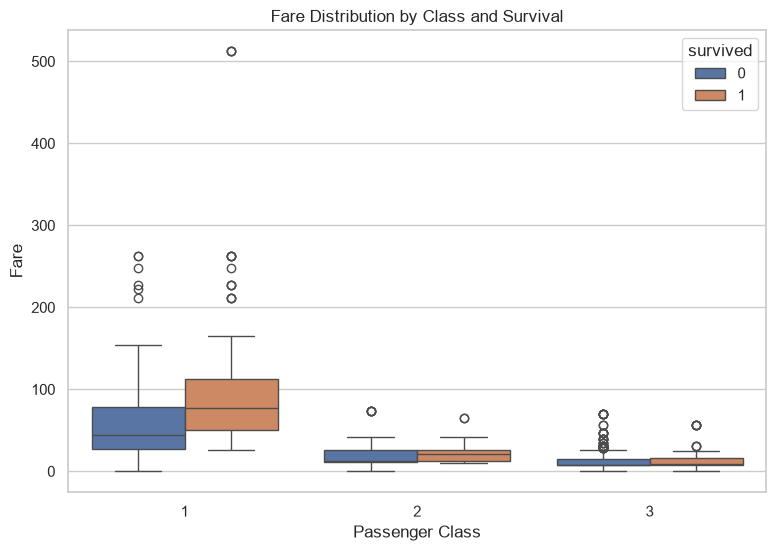

INTERPRETATION: Within passenger classes, survivors 
generally have higher fare distributions than 
non-survivors. Fare differences are especially visible 
in first class, although the distributions overlap 
within each class.


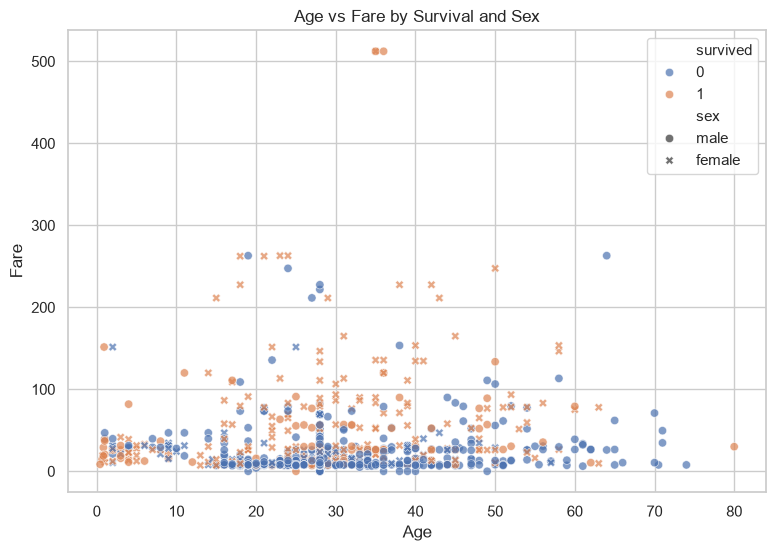

INTERPRETATION: Surviving passengers are more frequently 
observed at higher fare values across several age ranges. 
The plot also shows differences between male and female 
passengers, indicating that survival was associated with 
multiple characteristics rather than age alone.


In [17]:
# ------------------------------------------------------------
# Chart 1 — Survival rate by sex
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

sns.barplot(
    data=clean_df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

print(
    "INTERPRETATION: "
    f"Female passengers had a survival rate of \n"
    f"{survival_rate_female:.1f}%, compared with "
    f"{survival_rate_male:.1f}% for male passengers. \n"
    "The chart shows a substantial difference in survival \n"
    "rates between the two groups in this sample."
)

# ------------------------------------------------------------
# Chart 2 — Survival rate by passenger class
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

print(
    "INTERPRETATION: Survival rate decreases from first \n"
    "class to third class in this dataset. This pattern is\n"
    "consistent with the negative correlation between pclass\n"
    "and survived observed in the correlation matrix."
)

# ------------------------------------------------------------
# Chart 3 — Age distribution by survival
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

print(
    "INTERPRETATION: The age distributions of survivors and \n"
    "non-survivors overlap substantially. The survivor group \n"
    "has a somewhat lower median age, although age alone does \n"
    "not clearly separate the two groups."
)

# ------------------------------------------------------------
# Chart 4 — Fare and survival by passenger class
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title(
    "Fare Distribution by Class and Survival"
)

plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

print(
    "INTERPRETATION: Within passenger classes, survivors \n"
    "generally have higher fare distributions than \n"
    "non-survivors. Fare differences are especially visible \n"
    "in first class, although the distributions overlap \n"
    "within each class."
)

# ------------------------------------------------------------
# Chart 5 — Age vs fare by survival and sex
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title(
    "Age vs Fare by Survival and Sex"
)

plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

print(
    "INTERPRETATION: Surviving passengers are more frequently \n"
    "observed at higher fare values across several age ranges. \n"
    "The plot also shows differences between male and female \n"
    "passengers, indicating that survival was associated with \n"
    "multiple characteristics rather than age alone."
)

## EDA-stage standardization sanity check

In [18]:
# This standardization is ONLY an exploratory EDA check.
# It does NOT feed into the modeling pipeline.
# 02_modeling.ipynb performs its own preprocessing and scaling
# using the training data only.

columns_to_scale = [
    "age",
    "fare"
]

# ------------------------------------------------------------
# Before standardization
# ------------------------------------------------------------
print("BEFORE STANDARDIZATION")
print("=" * 50)

print(
    clean_df[
        columns_to_scale
    ].agg(["mean", "std"])
)

# ------------------------------------------------------------
# Standardize age and fare
# ------------------------------------------------------------
scaler = StandardScaler()

clean_df[
    ["age_scaled", "fare_scaled"]
] = scaler.fit_transform(
    clean_df[columns_to_scale]
)

# ------------------------------------------------------------
# After standardization
# ------------------------------------------------------------
print("AFTER STANDARDIZATION")
print("=" * 50)

print(
    clean_df[
        ["age_scaled", "fare_scaled"]
    ].agg(["mean", "std"])
)

# ------------------------------------------------------------
# Before / after comparison
# ------------------------------------------------------------
comparison = pd.DataFrame(
    {
        "Original Mean":
            clean_df[["age", "fare"]].mean(),

        "Original Std":
            clean_df[["age", "fare"]].std(),

        "Scaled Mean":
            clean_df[
                ["age_scaled", "fare_scaled"]
            ].mean().values,

        "Scaled Std":
            clean_df[
                ["age_scaled", "fare_scaled"]
            ].std().values,
    },
    index=["age", "fare"]
)

print("STANDARDIZATION COMPARISON")
print("=" * 50)

print(comparison)

print(
    "\nThe scaled means are approximately 0 and the scaled \n"
    "standard deviations are approximately 1, confirming \n"
    "that age and fare were successfully standardized."
)

BEFORE STANDARDIZATION
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504
AFTER STANDARDIZATION
        age_scaled   fare_scaled
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
STANDARDIZATION COMPARISON
      Original Mean  Original Std   Scaled Mean  Scaled Std
age       29.315152     12.984932  2.717486e-16    1.000563
fare      32.096681     49.697504  1.398706e-16    1.000563

The scaled means are approximately 0 and the scaled 
standard deviations are approximately 1, confirming 
that age and fare were successfully standardized.


## Finalize titanic.csv for the modeling handoff

In [19]:
# The initial titanic.csv was created immediately after loading
# the raw dataset, satisfying the offline snapshot requirement.
#
# Now save the cleaned dataset as the final titanic.csv.
# This overwrites the initial snapshot because 02_modeling.ipynb
# must read the cleaned dataset produced by this notebook.
#
# The EDA-only age_scaled and fare_scaled columns are removed
# before saving because this exploratory standardization must NOT
# feed into the modeling pipeline.

modeling_handoff_df = clean_df.drop(
    columns=[
        "age_scaled",
        "fare_scaled"
    ]
)

modeling_handoff_df.to_csv(
    "titanic.csv",
    index=False
)

print(
    "Final titanic.csv saved successfully."
)

print(
    "Final cleaned handoff shape:",
    modeling_handoff_df.shape
)

print(
    "02_modeling.ipynb should read this file using:"
)

print(
    'pd.read_csv("titanic.csv")'
)

print(
    "No second sns.load_dataset('titanic') call should be used."
)

Final titanic.csv saved successfully.
Final cleaned handoff shape: (889, 14)
02_modeling.ipynb should read this file using:
pd.read_csv("titanic.csv")
No second sns.load_dataset('titanic') call should be used.
